# Analysis of the feature importance of the baseline models


Analyze the importance of the features in the baseline models to try to explain the models.
Use this information to improve the features of the models.

In [1]:
import core.constants as c
from core.processing import ResultsModel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.inspection import permutation_importance


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load results from JSON and pickle files
with open(c.RICKD_BASELINE_RESULTS_SUMMARY_FILE, "r") as f:
    results_json = f.read()
results_model_loaded = ResultsModel.model_validate_json(results_json)

results_loaded = {}
trained_models_loaded = {}
for result in results_model_loaded.results:
    results_loaded[result.model_name] = {
        'test_accuracy': result.test_accuracy,
        'test_precision': result.test_precision,
        'test_recall': result.test_recall,
        'test_f1': result.test_f1,
        'test_roc_auc': result.test_roc_auc,
        'y_pred': np.array(result.y_pred),
        'y_pred_proba': np.array(result.y_pred_proba),
        'best_parameters': result.best_parameters,
        'best_score': result.best_score,
    }
    trained_models_loaded[result.model_name] = joblib.load(result.model_file)

results = results_loaded
trained_models = trained_models_loaded

In [3]:
# Load train and test sets from disk
X_train = pd.read_csv(c.RICKD_BASELINE_X_TRAIN_FILE, index_col=0)
X_test = pd.read_csv(c.RICKD_BASELINE_X_TEST_FILE, index_col=0)
y_train = pd.read_csv(c.RICKD_BASELINE_Y_TRAIN_FILE, index_col=0).squeeze()
y_test = pd.read_csv(c.RICKD_BASELINE_Y_TEST_FILE, index_col=0).squeeze()

In [4]:
def get_feature_importance(model_name, model, X_data, y_data):
    classifier = model.best_estimator_.named_steps['classifier']
    feature_names = X_data.columns
    
    if hasattr(classifier, 'feature_importances_'):
        # Tree-based models (Random Forest, XGBoost)
        print(f"Using feature_importances_ for {model_name}...")
        importance_values = classifier.feature_importances_
        importance_type = 'Built-in'
        
    elif hasattr(classifier, 'coef_'):
        # Linear models (Logistic Regression) or SVM with linear kernel
        print(f"Using coef_ for {model_name}...")
        importance_values = np.abs(classifier.coef_[0])  # Use absolute values of coefficients
        importance_type = 'Coefficient Magnitude'
        
    else:
        # Models without built-in importance (SVM with RBF kernel) - use permutation importance
        # TODO: Should we use a different approach: SHAP or LOFO?
        print(f"Computing permutation importance for {model_name}...")
        perm_importance = permutation_importance(
            model, X_data, y_data, 
            n_repeats=10, 
            random_state=RANDOM_STATE,
            scoring='roc_auc'
        )
        importance_values = perm_importance.importances_mean
        importance_type = 'Permutation'
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_values,
        'importance_type': importance_type
    }).sort_values('importance', ascending=False)
    
    return importance_df

all_feature_importance = {}

for model_name, model in trained_models.items():
    print(f"Extracting feature importance for {model_name}...")
    importance_df = get_feature_importance(model_name, model, X_test, y_test)
    all_feature_importance[model_name] = importance_df

Extracting feature importance for Logistic Regression...
Using coef_ for Logistic Regression...
Extracting feature importance for Random Forest...
Using feature_importances_ for Random Forest...
Extracting feature importance for XGBoost...
Using feature_importances_ for XGBoost...
Extracting feature importance for SVM...
Computing permutation importance for SVM...


## Feature Importance Visualization

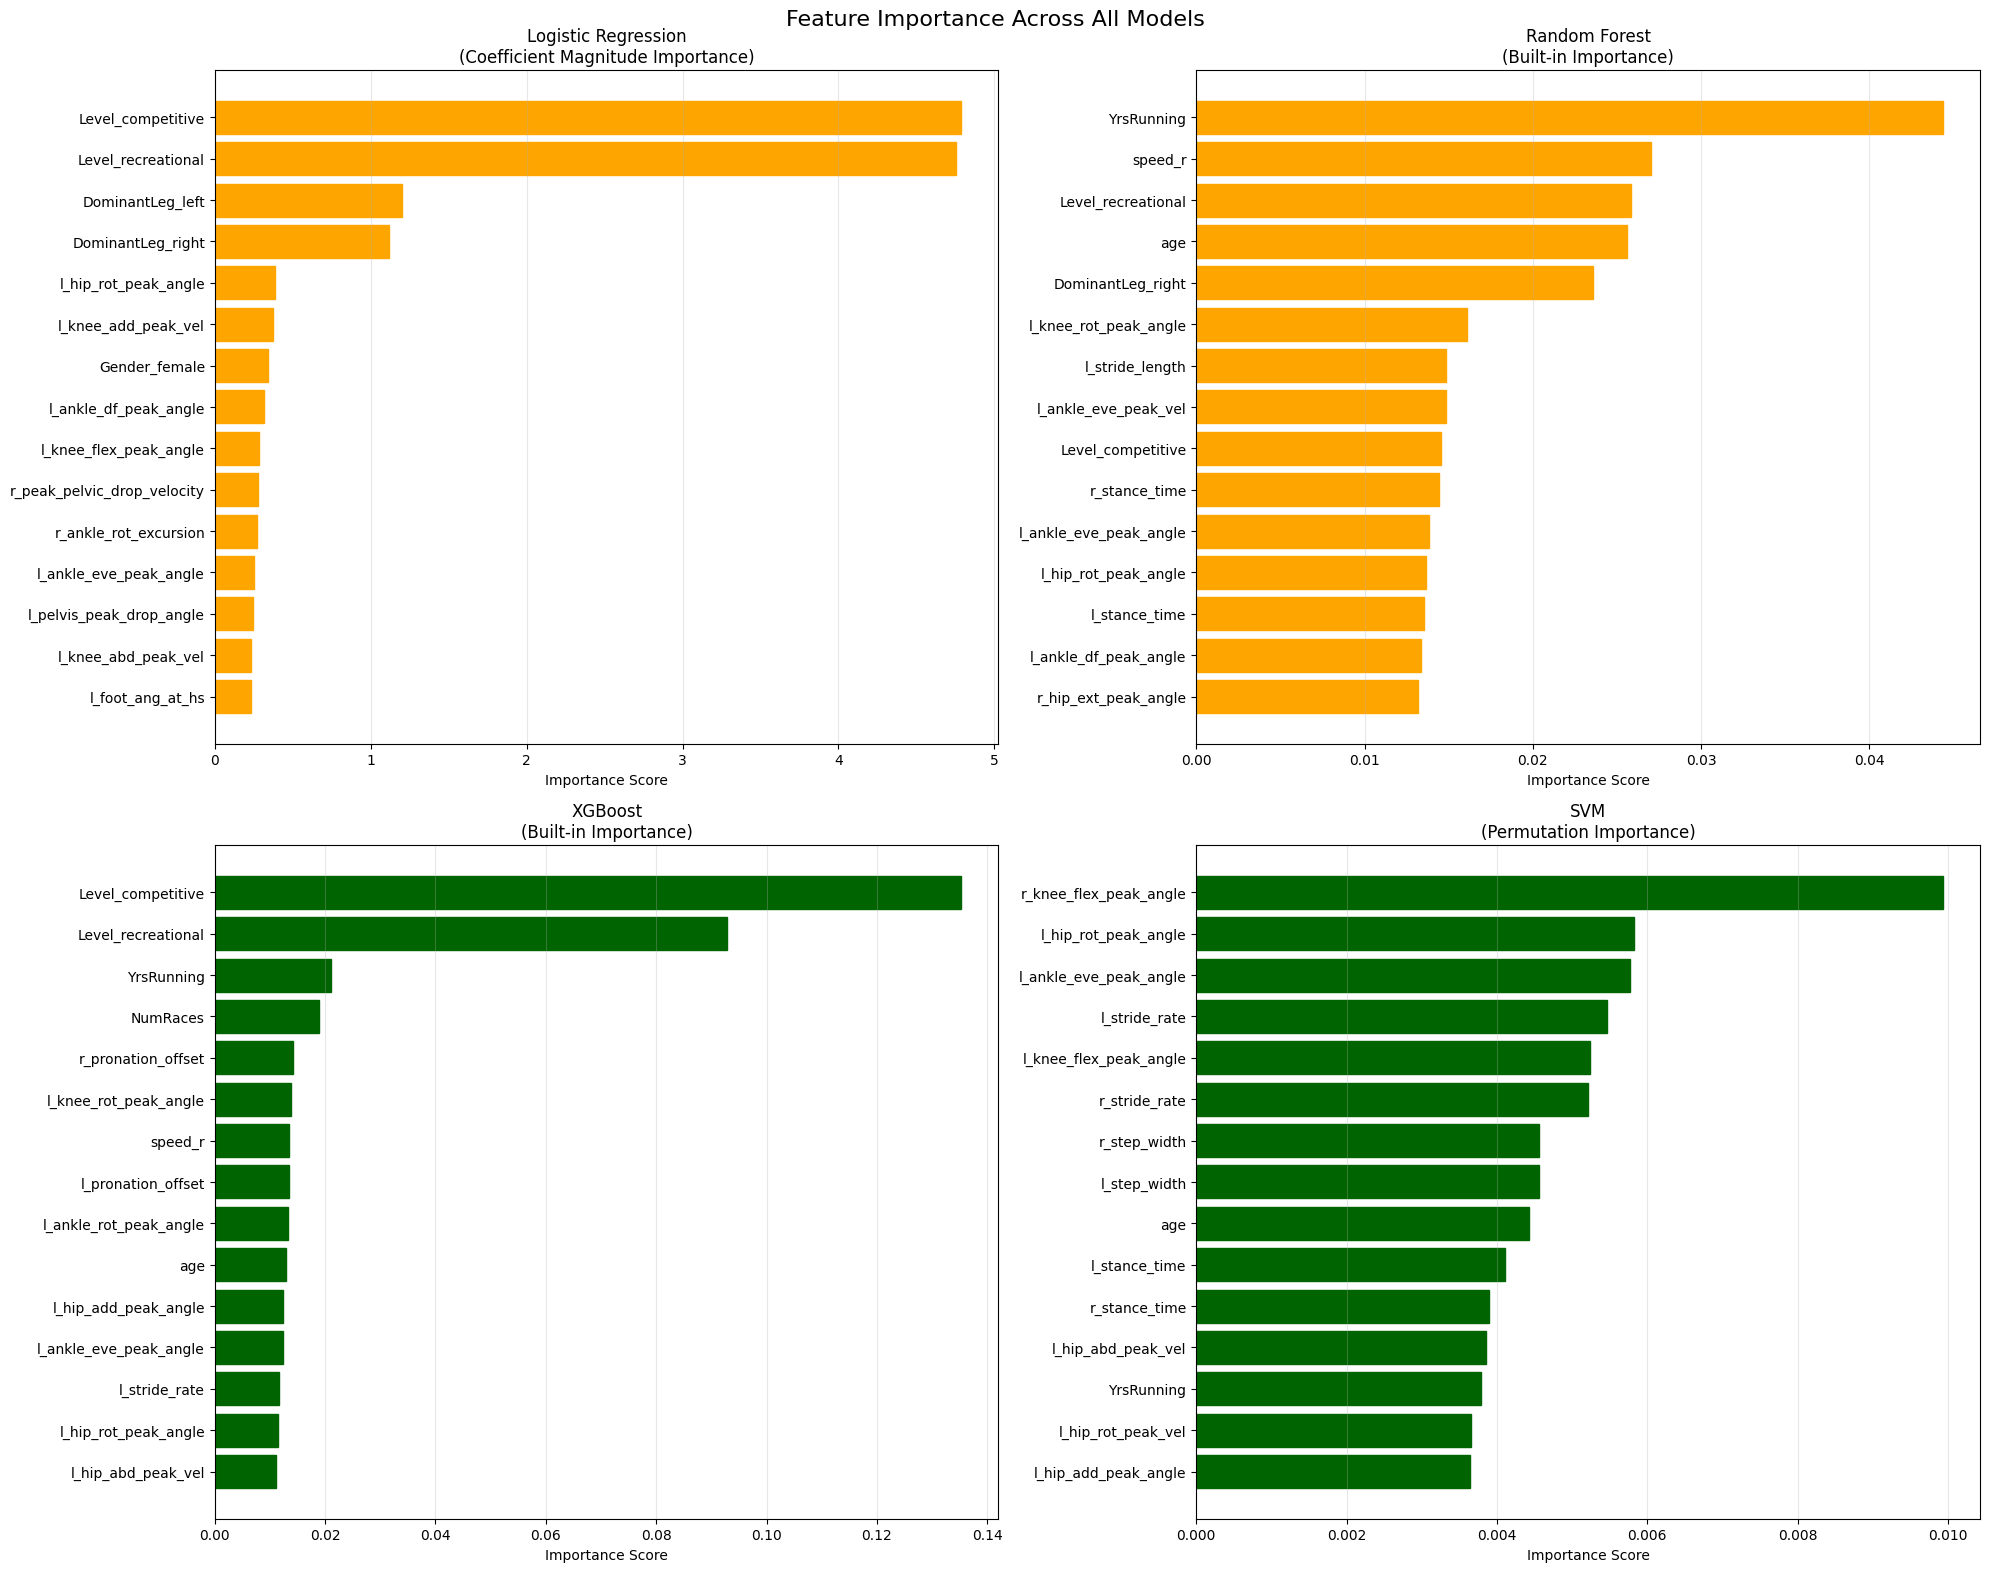

In [5]:
# Individual feature importance plots for each model
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

for idx, (model_name, importance_df) in enumerate(all_feature_importance.items()):
    ax = axes[idx]
    
    # Plot top 15 features for each model
    top_features = importance_df.head(15)
    bars = ax.barh(range(len(top_features)), top_features['importance'])
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'], fontsize=10)
    ax.set_xlabel('Importance Score')
    ax.set_title(f'{model_name}\n({top_features["importance_type"].iloc[0]} Importance)', fontsize=12)
    ax.invert_yaxis()
    
    # Color bars based on performance
    model_auc = results[model_name]['test_roc_auc']
    if model_auc > 0.8:
        color = 'darkgreen'
    elif model_auc > 0.77:
        color = 'orange'
    else:
        color = 'lightcoral'
    
    for bar in bars:
        bar.set_color(color)
    
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Across All Models', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()


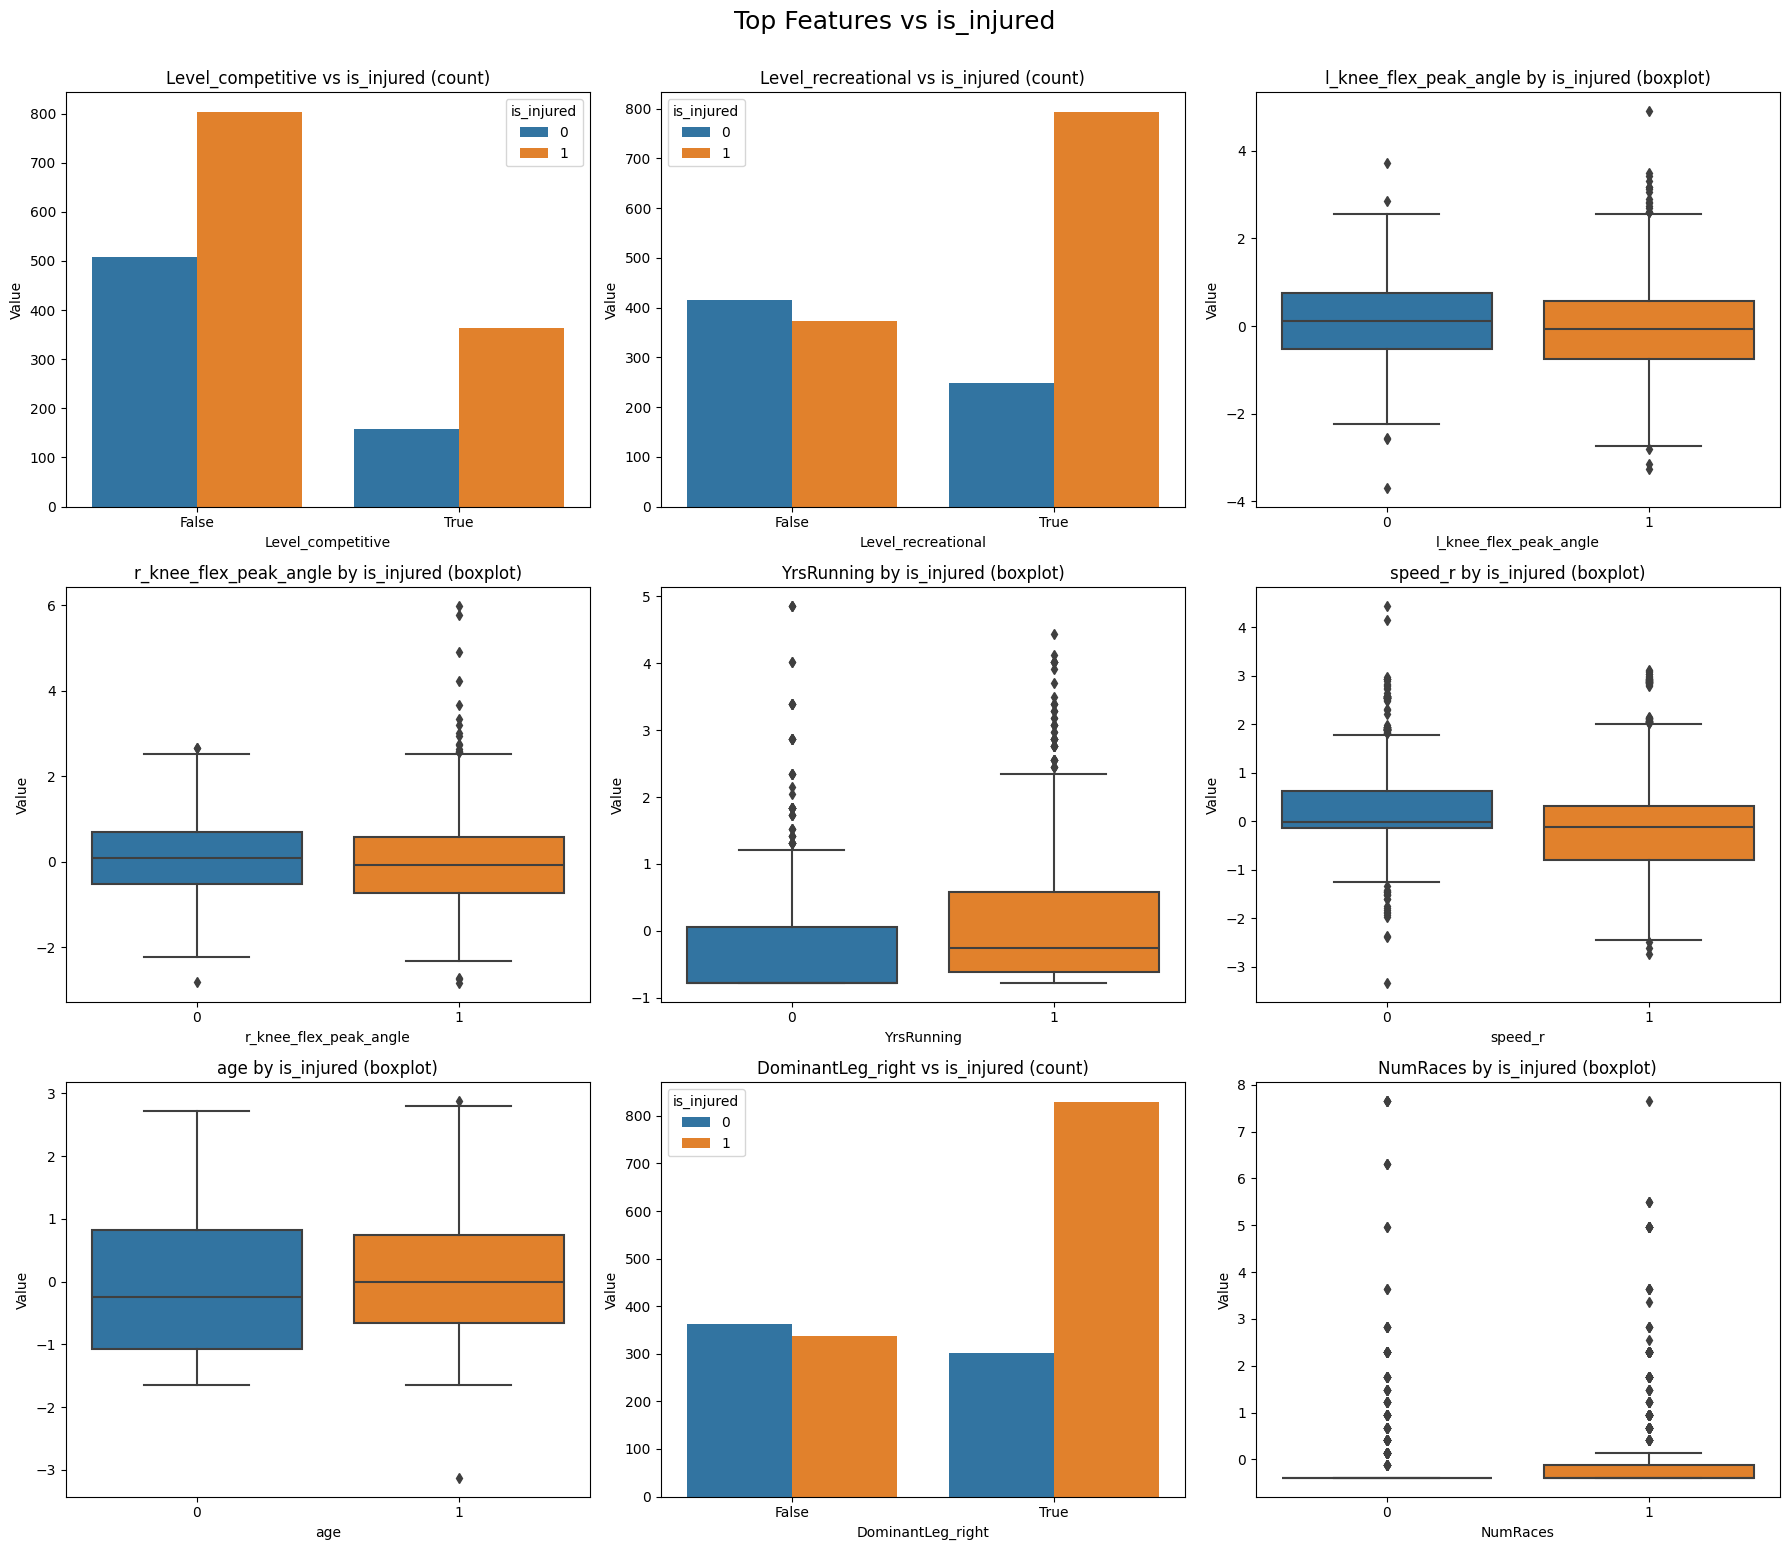

In [6]:
import seaborn as sns


X = pd.read_csv(c.RICKD_BASELINE_X_FILE, index_col=0)
y = pd.read_csv(c.RICKD_BASELINE_Y_FILE, index_col=0)


top_features_to_check = [
    'Level_competitive',
    'Level_recreational',
    'l_knee_flex_peak_angle',
    'r_knee_flex_peak_angle',
    'YrsRunning',
    'speed_r',
    'age',
    'DominantLeg_right',
    "NumRaces",
]

# Combine X and y for plotting
data = X.copy()
data['is_injured'] = y['is_injured']

n_features = len(top_features_to_check)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(top_features_to_check):
    ax = axes[i]
    if data[feature].nunique() <= 5 and data[feature].dtype in [int, bool, object]:
        # Categorical or binary feature
        sns.countplot(data=data, x=feature, hue='is_injured', ax=ax)
        ax.set_title(f"{feature} vs is_injured (count)")
    else:
        # Continuous feature
        sns.boxplot(data=data, x='is_injured', y=feature, ax=ax)
        ax.set_title(f"{feature} by is_injured (boxplot)")
    ax.set_xlabel(feature)
    ax.set_ylabel('Value')

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Top Features vs is_injured", fontsize=18, y=1.03)
plt.show()
